In [1]:
from definitions import *
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def mse_loss(circuit: qml.Qnode, theta: np.ndarray, collocation_points: np.ndarray, target: Callable):
    return qml.numpy.mean((circuit(collocation_points, theta) - target(collocation_points))**2)

In [19]:
device = qml.device('default.qubit', wires=N_QUBITS)
rng = qml.numpy.random.default_rng(42)

In [41]:
target = generate_random_instance(optimal_pauli_combination_circuit, device)
circuit = qml.QNode(optimal_pauli_combination_circuit, device)

N_COLLOCATION_POINTS = 30
collocation_points = np.linspace(0, 2*np.pi, N_COLLOCATION_POINTS)
# collocation_points = np.array([0, 1., 2.])

def cost(theta: np.ndarray):
    return mse_loss(circuit, theta, collocation_points, target)

optimiser = qml.AdamOptimizer(stepsize=0.01)
loss_values = []
N_STEPS = 3000
theta = 2*np.pi*rng.random(6*N_QUBITS, requires_grad=True)

In [42]:
loss_values = np.zeros(N_STEPS)
for step in tqdm(range(N_STEPS), total=N_STEPS):
    theta, loss_values[step] = optimiser.step_and_cost(cost, theta)

100%|██████████| 3000/3000 [00:50<00:00, 58.97it/s]


Final loss value: 7.33e-05


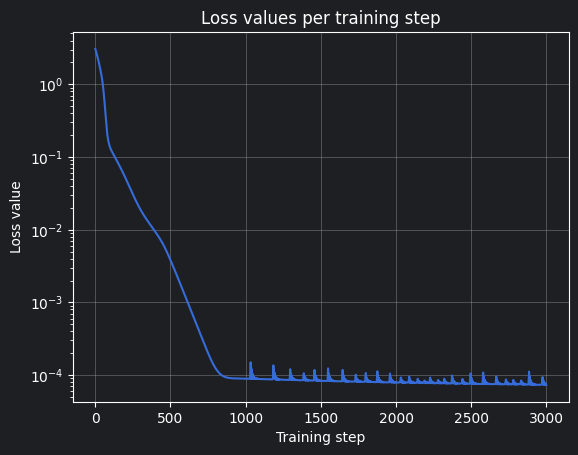

In [43]:
plt.semilogy(loss_values)
plt.title("Loss values per training step")
plt.xlabel("Training step")
plt.ylabel("Loss value")
plt.grid()

print(f"Final loss value: {loss_values[-1]:.2e}")

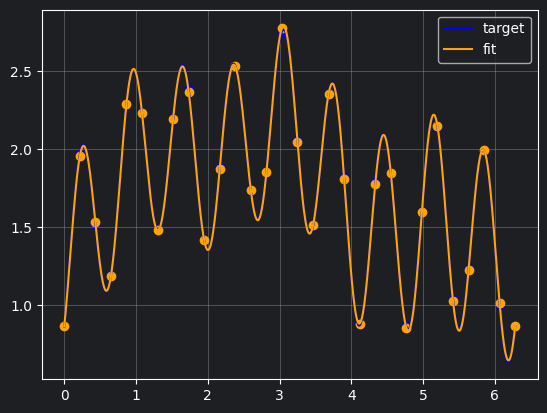

In [44]:
xs = np.linspace(0, 2*np.pi, 1000)
plt.plot(xs, target(xs), color='blue', label='target')
plt.scatter(collocation_points, target(collocation_points), color='blue')
plt.plot(xs, circuit(xs, theta), color='orange', label='fit')
plt.scatter(collocation_points, circuit(collocation_points, theta), color='orange')
plt.legend()
plt.grid()

In [45]:
print(np.sqrt(mse_loss(circuit, theta, xs, target)))

0.008722941216121468
